##  라이브러리 불러오기

In [2]:
# pip install pandas matplotlib wordcloud scikit-learn

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import html


## 데이터 불러오기

In [3]:
df = pd.read_csv("./data/Sentiment140.csv", encoding="latin1")
df

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
...,...,...,...,...,...,...
1599994,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599995,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599996,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599997,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [69]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1599999 entries, 0 to 1599998
Data columns (total 6 columns):
 #   Column                                                                                                               Non-Null Count    Dtype
---  ------                                                                                                               --------------    -----
 0   0                                                                                                                    1599999 non-null  int64
 1   1467810369                                                                                                           1599999 non-null  int64
 2   Mon Apr 06 22:19:45 PDT 2009                                                                                         1599999 non-null  str  
 3   NO_QUERY                                                                                                             1599999 non-null  str  
 4   _TheSpecialOne_   

## 데이터 정제

컬럼명 변환

In [70]:
df = df.rename(columns={'0':'sentiment', "1467810369": "ID", "Mon Apr 06 22:19:45 PDT 2009":"upload_time", "_TheSpecialOne_":"username", "@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D":"comment"})
df.head()

,sentiment,ID,upload_time,NO_QUERY,username,comment
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [71]:
df.groupby(['NO_QUERY']).count()

,sentiment,ID,upload_time,username,comment
NO_QUERY,,,,,
NO_QUERY,1599999,1599999,1599999,1599999,1599999


In [72]:
# NO_QUERY밖에 없음. 해당 컬럼 삭제.
df = df.drop(columns=["NO_QUERY", "username"])
df.head()

,sentiment,ID,upload_time,comment
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,@Kwesidei not the whole crew


In [73]:
df.groupby(['sentiment']).count()

# 부정 799999개, 긍정 800000개

,ID,upload_time,comment
sentiment,,,
0,799999,799999,799999
4,800000,800000,800000


In [74]:
custom_stopwords = ENGLISH_STOP_WORDS.union({"lol", "think", "im", "today"}) # 의미없는 용어 제외


def clean_text(text):
    text = html.unescape(text)  # &amp; -> &, &quot; -> " 등으로 먼저 변환
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # 특수문자 제거 (이제 amp, quot가 안 남음)
    text = " ".join([w for w in text.split() if w not in custom_stopwords])
    return text

df["comment"] = df["comment"].apply(clean_text)
print(df)

         sentiment          ID                   upload_time  \
0                0  1467810672  Mon Apr 06 22:19:49 PDT 2009   
1                0  1467810917  Mon Apr 06 22:19:53 PDT 2009   
2                0  1467811184  Mon Apr 06 22:19:57 PDT 2009   
3                0  1467811193  Mon Apr 06 22:19:57 PDT 2009   
4                0  1467811372  Mon Apr 06 22:20:00 PDT 2009   
...            ...         ...                           ...   
1599994          4  2193601966  Tue Jun 16 08:40:49 PDT 2009   
1599995          4  2193601969  Tue Jun 16 08:40:49 PDT 2009   
1599996          4  2193601991  Tue Jun 16 08:40:49 PDT 2009   
1599997          4  2193602064  Tue Jun 16 08:40:49 PDT 2009   
1599998          4  2193602129  Tue Jun 16 08:40:50 PDT 2009   

                                                   comment  
0         upset update facebook texting result school blah  
1        kenichan dived times ball managed save rest bo...  
2                                    body feels 

## 긍정/부정 데이터 분리

In [75]:
positive_df = df[df["sentiment"] == 4]
negative_df = df[df["sentiment"] == 0]

print("긍정 댓글 수: ", len(positive_df))
print("부정 댓글 수: ", len(negative_df))

긍정 댓글 수:  800000
부정 댓글 수:  799999


## 워드클라우드용 텍스트 합치기

In [ ]:
SAMPLE_SIZE = 50000  # 전체 80만 개 중 일부만 샘플링

positive_sample = positive_df["comment"].dropna().sample(n=SAMPLE_SIZE, random_state=42)
negative_sample = negative_df["comment"].dropna().sample(n=SAMPLE_SIZE, random_state=42)

positive_text = " ".join(positive_sample)
negative_text = " ".join(negative_sample)

## 워드클라우드 생성

In [77]:
positive_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200,
    random_state=42
).generate(positive_text)

negative_wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=200,
    random_state=42
).generate(negative_text)

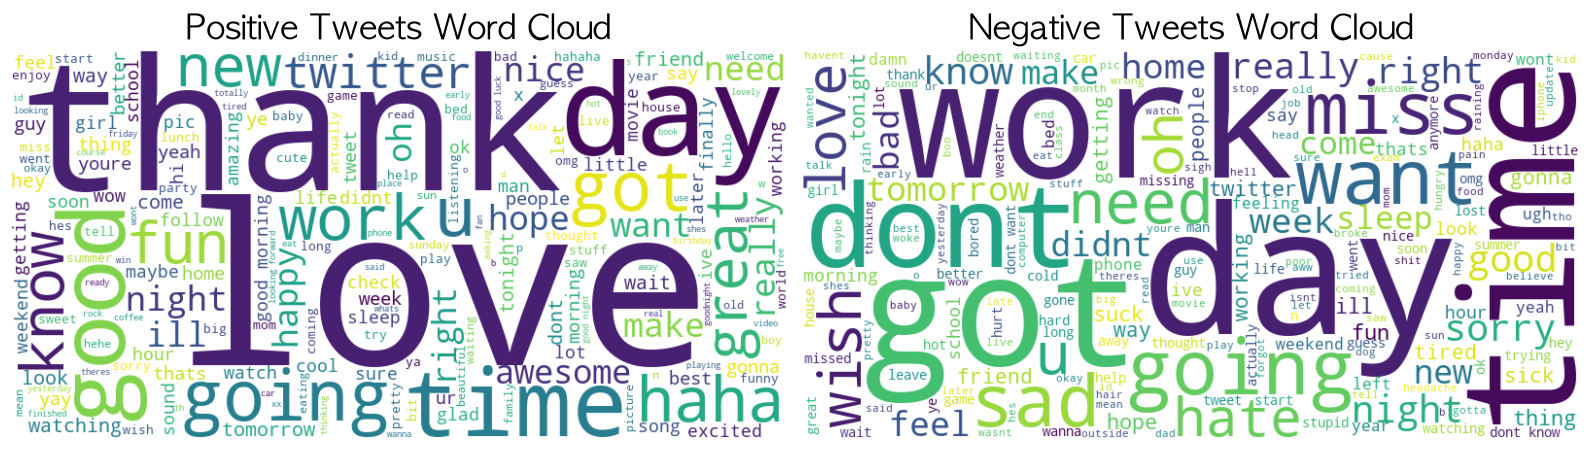

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(positive_wc, interpolation="bilinear")
axes[0].set_title("Positive Tweets Word Cloud", fontsize=24)
axes[0].axis("off")

axes[1].imshow(negative_wc, interpolation="bilinear")
axes[1].set_title("Negative Tweets Word Cloud", fontsize=24)
axes[1].axis("off")

plt.tight_layout()
plt.show()